In [2]:
import iris,glob
import scipy as sp
from scipy.special import erf
import calendar  # Import the calendar module
import matplotlib.pyplot as plt
import iris.plot as iplt
import cartopy.crs as ccrs
import numpy as np
import iris.coord_systems as cs
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import matplotlib as mpl
import matplotlib.ticker as mticker
import matplotlib.patches as patches
from iris.analysis.cartography import wrap_lons
from matplotlib.colors import LogNorm
import iris.quickplot as qplt
from scipy.spatial import cKDTree
from datetime import datetime, timedelta
import numpy.ma as ma
import pandas as pd
import statistics
import cartopy.feature as cfeature
import iris.plot as iplt
from datetime import datetime, timedelta
import matplotlib.colors as mcolors
import matplotlib.image as mpimg
import metpy.calc as mpcalc
from metpy.units import units
from scipy.stats import norm
import netCDF4 as nc
#from sklearn.metrics import mean_squared_error
from tqdm import tqdm
from netCDF4 import Dataset
import os
from pylab import *

In [ ]:
test

## Run pb_mass_reg.py and aerosol_radii.py 

In [ ]:
#suite = 'do764'
#suite = 'do765'
#suite = 'do766'
suite = 'dn827'


#campaign = 'ATom-1'
#campaign = 'ATom-2'
#campaign = 'ATom-3'
campaign = 'ATom-4'

#month = 'jul'
#month = 'jan'
#month = 'sep'
month = 'apr'

#year = 2016
#year = 2017
year = 2018



file_base=[f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/']
dirs = file_base

print(dirs)
umfile=1
iris_version=2.0

#def lognormal_cumulative(N,r,rbar,sigma):
#    total=(N/2)*(1+sp.special.erf(np.log10(r/rbar)/np.sqrt(2)/np.log10(sigma)))  #number concentration lognormal distribution
#    return total

def load_with(filepath,constraint):
  if umfile==1 and iris_version==2:
    from iris.fileformats.um import structured_um_loading
    with structured_um_loading():
      cube = iris.load_cube(filepath,constraint)
  else:
    cube = iris.load_cube(filepath,constraint)
  return cube   



['/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/ATom-4/History_Data/']


In [ ]:
# Define campaign (e.g., 'ATom-1', 'ATom-2', etc.)


# --- Load all soluble and insoluble mode radii cubes ---
ait_mode_radius = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/aitsol_radius.nc')
acc_mode_radius = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/accsol_radius.nc')
cor_mode_radius = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/corsol_radius.nc')

aitins_mode_radius = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/aitinsol_radius.nc')
accins_mode_radius = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/accinsol_radius.nc')
corins_mode_radius = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/corinsol_radius.nc')

# --- Subset first 11 time steps (or levels) ---
ait_mode_radius = ait_mode_radius[:, 0:11]
acc_mode_radius = acc_mode_radius[:, 0:11]
cor_mode_radius = cor_mode_radius[:, 0:11]

aitins_mode_radius = aitins_mode_radius[:, 0:11]
accins_mode_radius = accins_mode_radius[:, 0:11]
corins_mode_radius = corins_mode_radius[:, 0:11]

# --- Load all soluble and insoluble mode concentration cubes ---
ait_mode_conc = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/aitsol_number.nc')
acc_mode_conc = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/accsol_number.nc')
cor_mode_conc = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/corsol_number.nc')

aitins_mode_conc = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/aitinsol_number.nc')
accins_mode_conc = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/accinsol_number.nc')
corins_mode_conc = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/corinsol_number.nc')


# --- Subset first 11 levels ---
ait_mode_conc = ait_mode_conc[:, 0:11]* 1e-6
acc_mode_conc = acc_mode_conc[:, 0:11]* 1e-6
cor_mode_conc = cor_mode_conc[:, 0:11]* 1e-6

aitins_mode_conc = aitins_mode_conc[:, 0:11]* 1e-6
accins_mode_conc = accins_mode_conc[:, 0:11]* 1e-6
corins_mode_conc = corins_mode_conc[:, 0:11]* 1e-6





## Run log_cum.py

## ATom data

In [ ]:

from datetime import datetime, timedelta

land_sea_file = '/jet/home/nasch/IMERG_land_sea_mask.nc'  ##just aqua

land_sea_mask = Dataset(land_sea_file, mode='r')
print(land_sea_mask.variables.keys())
land_sea_mask_values = land_sea_mask['landseamask'][:]   ##100 = all water and 0 = all land
land_sea_mask_lat = land_sea_mask['lat'][:]
land_sea_mask_lon = land_sea_mask['lon'][:]


file_path_aerosol = '/jet/home/nasch/tmp_ondemand_ocean_atm200005p_symlink/earhg/observations/ATom_Aerosol_Properties_V2_2111/data/ATom_60s_aerosol_data.nc'  ##just aqua
###All ATom events


aerosol_data = Dataset(file_path_aerosol, mode='r')
print(aerosol_data.variables.keys())
aerosol_data.variables['DateTime_UTC']
#aerosol_data.variables['time']
latitude = aerosol_data.variables['latitude'][:]

# Assuming you have the DateTime_UTC data in a variable
# For demonstration purposes, we'll use a mock variable, replace this with the actual data.
# For example, `DateTime_UTC` data could be extracted like this:
# datetime_utc_data = dataset.variables['DateTime_UTC'][:]
# Here I use a mock dataset for demonstration.

datetime_utc_data = aerosol_data.variables['DateTime_UTC'][:]

# Define the base reference time (1904-01-01 00:00:00)
base_time = datetime(1904, 1, 1)

# Convert seconds to datetime
converted_dates = [base_time + timedelta(seconds=sec) for sec in datetime_utc_data]

aerosol_timestamps = np.array([dt.strftime('%Y-%m-%d %H:%M') for dt in converted_dates])


np.shape(aerosol_timestamps)

latitude_aerosol = aerosol_data.variables['latitude'][:]
longitude_aerosol = aerosol_data.variables['longitude'][:]
num_accum_aerosol = aerosol_data.variables['num_accum'][:]
w_aerosol = aerosol_data.variables['W']
altitude_aerosol = aerosol_data.variables['gps_altitude'][:]




# Define campaign names and corresponding slices
campaign_abbr = ["atom1", "atom2", "atom3", "atom4"]
campaign_slices = [
    slice(0, 5440),       # ATom-1
    slice(5450, 11080),     # ATom-2
    slice(11090, 17810),    # ATom-3
    slice(17820, None)      # ATom-4 (until end)
]

# Dictionary to store variables
data = {}

for campaign_name, campaign_slice in zip(campaign_abbr, campaign_slices):
    # Assign values dynamically with correct slice
    data[f"time_{campaign_name}"] = datetime_utc_data[campaign_slice]
    data[f"latitude_{campaign_name}"] = latitude_aerosol[campaign_slice]
    data[f"longitude_{campaign_name}"] = longitude_aerosol[campaign_slice]
    data[f"num_accum_{campaign_name}"] = num_accum_aerosol[campaign_slice]
    data[f"w_{campaign_name}"] = w_aerosol[campaign_slice]
    data[f"altitude_{campaign_name}"] = altitude_aerosol[campaign_slice]
    

    # Print NaN and masked counts
    print(f"NaN count in num_accum_{campaign_name}:",
          np.isnan(data[f"num_accum_{campaign_name}"]).sum())
    print(f"Masked count in num_accum_{campaign_name}:",
          np.ma.count_masked(data[f"num_accum_{campaign_name}"]))

    # Create a unified mask based on altitude > 1000 or existing mask in num_accum
    mask = (data[f"altitude_{campaign_name}"] > 1000) | np.ma.getmaskarray(data[f"num_accum_{campaign_name}"])
    

    # Apply the mask to all relevant variables
    for key in ["time", "latitude", "longitude", "num_accum", "altitude"]:
        data[f"{key}_{campaign_name}"] = np.ma.masked_where(mask, data[f"{key}_{campaign_name}"])

# If needed, store results as global variables
globals().update(data)

dict_keys(['lon', 'lat', 'landseamask'])
dict_keys(['BB_dndlogd', 'BB_dndlogd_ambRH', 'BC_abs_ambPT', 'BrC_abs_ambPT', 'CCN_005', 'CCN_010', 'CCN_020', 'CCN_050', 'CCN_100', 'CO', 'DateTime_UTC', 'Diameter', 'EC_dndlogd', 'EC_dndlogd_ambRH', 'MEE_ambRH', 'MEE_dry', 'RHw_DLH', 'SSA_ambRH', 'SSA_dry', 'SS_coarse_calc', 'SS_dndlogd', 'SS_dndlogd_ambRH', 'SS_fine_calc', 'U', 'V', 'W', 'Wavelength', 'abs_Angstrom_UV_Vis', 'abs_Angstrom_Vis_IR', 'alk_coarse_calc', 'alk_dndlogd', 'alk_dndlogd_ambRH', 'alk_fine_calc', 'ambient_pressure', 'ambient_temperature', 'ammonium_calc', 'asymmetry_amRH', 'asymmetry_dry', 'backscat_ambRHPT', 'backscatt_eff_ambRH', 'chl_calc', 'comb_dndlogd', 'comb_dndlogd_ambRH', 'dndlogd', 'dndlogd_ambRH', 'dust_coarse_calc', 'dust_dndlogd', 'dust_dndlogd_ambRH', 'dust_fine_calc', 'ext_Angstrom_dry', 'ext_Angstrom_dry_uv_vis', 'ext_Angstrom_dry_vis_ir', 'ext_ambRHPT', 'ext_angstrom_ambRH', 'ext_angstrom_ambRH_uv_vis', 'ext_angstrom_ambRH_vis_ir', 'ext_backscat_ratio_amb

In [208]:
N_frac_ait = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/N_frac_AIT_1000.nc')
N_frac_ait_ins = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/N_frac_AITINS_1000.nc')
N_frac_acc = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/N_frac_ACC_1000.nc')
N_frac_acc_ins = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/N_frac_ACCINS_1000.nc')
N_frac_cor = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/N_frac_COR_1000.nc')
N_frac_cor_ins = iris.load_cube(f'/ocean/projects/atm200005p/nasch/ATom/simulation_spinup/{campaign}/History_Data/N_frac_CORINS_1000.nc')


## Run interpolation.py

In [245]:
df = pd.read_csv('atom_4_matched_model.csv')
df.tail()

,time,latitude,longitude,altitude_m,num_accum_atom,model_accum,model_accum_insoluble,model_aitken,model_aitken_insoluble,model_cor,model_cor_insoluble
637,2018-05-21 22:59:31.260,36.20709,240.9342,471.8770,2661.851,152.756524,32.522334,94.544143,21.249976,0.271930,0.388928
638,2018-05-21 23:00:31.270,36.14984,240.9042,469.0000,2478.255,152.756524,32.522334,94.544143,21.249976,0.271930,0.388928
639,2018-05-21 23:01:24.890,36.11417,240.8453,468.1122,2339.648,152.756524,32.522334,94.544143,21.249976,0.271930,0.388928
640,2018-05-21 23:02:29.790,36.07220,240.7722,477.3443,2655.864,151.255329,32.340154,93.926857,20.848337,0.268906,0.386474
641,2018-05-21 23:03:29.800,36.01717,240.7393,807.7082,3362.456,147.711022,31.945401,92.403149,19.962523,0.261068,0.381120


In [3]:
df1 = pd.read_csv(f'atom_1_matched_model.csv')
df2 = pd.read_csv(f'atom_2_matched_model.csv')
df3 = pd.read_csv(f'atom_3_matched_model.csv')
df4 = pd.read_csv(f'atom_4_matched_model.csv')

df_combined = pd.concat([df1, df2, df3, df4], ignore_index=True)

num_accum_obs_masked = df_combined['num_accum_atom']  ##altitiude less than 1 km
num_accum_model_masked = df_combined['model_accum']
num_accum_ins_model_masked = df_combined['model_accum_insoluble']
aitken_model_masked = df_combined['model_aitken']
aitken_ins_model_masked = df_combined['model_aitken_insoluble']
cor_model_masked = df_combined['model_cor']
cor_ins_model_masked = df_combined['model_cor_insoluble']

total_conc = num_accum_model_masked + num_accum_ins_model_masked + aitken_model_masked + aitken_ins_model_masked + cor_model_masked + cor_ins_model_masked


total_obs = df_combined['num_accum_atom']
lat_obs = df_combined['latitude']
lon_obs = df_combined['longitude']

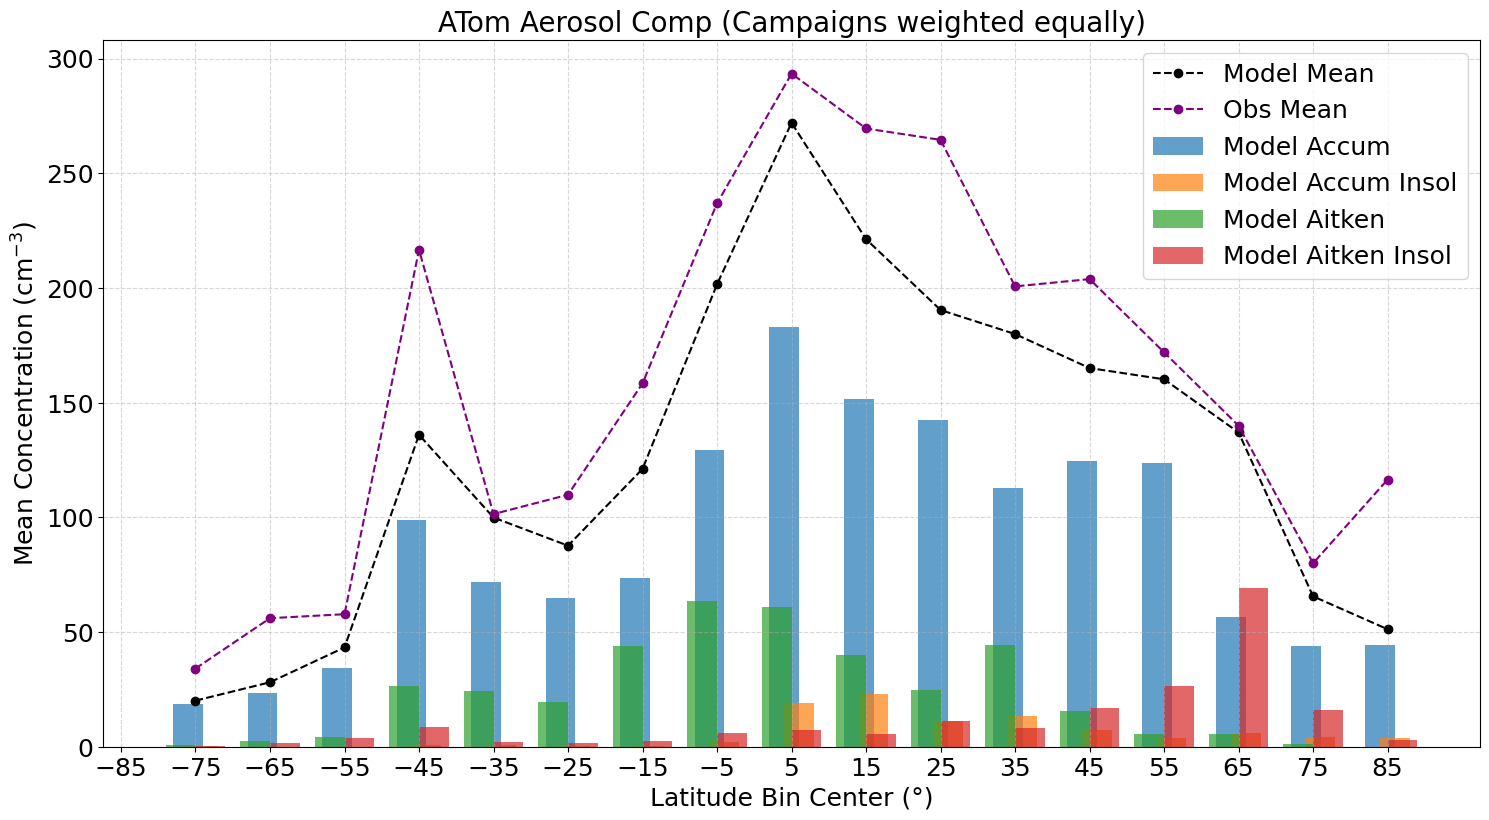

In [3]:
# Load individual campaign dataframes
dfs = {
    'ATom-1': pd.read_csv('atom_1_matched_model.csv'),
    'ATom-2': pd.read_csv('atom_2_matched_model.csv'),
    'ATom-3': pd.read_csv('atom_3_matched_model.csv'),
    'ATom-4': pd.read_csv('atom_4_matched_model.csv'),
}


lat_bins = np.arange(-90, 91, 10)
lat_bin_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
thres = 1000

# Initialize dictionaries to store campaign means
mean_fields = ['accum', 'accum_ins', 'aitken', 'aitken_ins', 'cor', 'cor_ins', 'total', 'obs']
campaign_means = {key: [] for key in mean_fields}

for lat_min, lat_max in zip(lat_bins[:-1], lat_bins[1:]):
    # Temporary storage for each campaign's mean per bin
    campaign_bin_means = {key: [] for key in mean_fields}

    for name, df in dfs.items():
        lat = df['latitude']
        mask = (lat >= lat_min) & (lat < lat_max)

        if not mask.any():
            continue  # skip this campaign if it has no points in this bin

        def masked_mean(var):
            m = var[mask]
            m = m[m <= thres]
            return np.nanmean(m) if len(m) > 0 else np.nan

        acc = df['model_accum']
        acc_ins = df['model_accum_insoluble']
        ait = df['model_aitken']
        ait_ins = df['model_aitken_insoluble']
        cor = df['model_cor']
        cor_ins = df['model_cor_insoluble']
        obs = df['num_accum_atom']

        total = acc + acc_ins + ait + ait_ins + cor + cor_ins

        # Collect means for this campaign in this lat bin
        campaign_bin_means['accum'].append(masked_mean(acc))
        campaign_bin_means['accum_ins'].append(masked_mean(acc_ins))
        campaign_bin_means['aitken'].append(masked_mean(ait))
        campaign_bin_means['aitken_ins'].append(masked_mean(ait_ins))
        campaign_bin_means['cor'].append(masked_mean(cor))
        campaign_bin_means['cor_ins'].append(masked_mean(cor_ins))
        campaign_bin_means['total'].append(masked_mean(total))
        campaign_bin_means['obs'].append(masked_mean(obs))

    # After collecting all campaigns for this bin, average them equally
    for key in mean_fields:
        vals = campaign_bin_means[key]
        campaign_means[key].append(np.nanmean(vals) if len(vals) > 0 else np.nan)


accum_mean      = np.array(campaign_means['accum'])
accum_ins_mean  = np.array(campaign_means['accum_ins'])
aitken_mean     = np.array(campaign_means['aitken'])
aitken_ins_mean = np.array(campaign_means['aitken_ins'])
cor_mean        = np.array(campaign_means['cor'])
cor_ins_mean    = np.array(campaign_means['cor_ins'])
total_mean      = np.array(campaign_means['total'])
total_obs_mean  = np.array(campaign_means['obs'])

# Bar width and x locations
bar_width = 4  # degrees wide for visual clarity
x = lat_bin_centers

plt.figure(figsize=(15, 8))

# Plotting each mode's mean with transparency for overlap visibility
plt.bar(x - 0.25*bar_width, accum_mean, width=bar_width, label='Model Accum', color='tab:blue', alpha=0.7)
plt.bar(x + 0.25*bar_width, accum_ins_mean, width=bar_width, label='Model Accum Insol', color='tab:orange', alpha=0.7)
plt.bar(x - 0.5*bar_width, aitken_mean, width=bar_width, label='Model Aitken', color='tab:green', alpha=0.7)
plt.bar(x + 0.5*bar_width, aitken_ins_mean, width=bar_width, label='Model Aitken Insol', color='tab:red', alpha=0.7)
plt.plot(x, total_mean, marker='o', linestyle='--', color='black', label='Model Mean')
plt.plot(x, total_obs_mean, marker='o', linestyle='--', color='purple', label='Obs Mean')

# Aesthetics
fontsize_all = 18
plt.xlabel('Latitude Bin Center (°)', fontsize=fontsize_all)
plt.ylabel('Mean Concentration (cm$^{-3}$)', fontsize=fontsize_all)
# plt.title('Mean Mode Concentrations by Latitude Bin (80nm–1µm)', fontsize=fontsize_all)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(lat_bin_centers, fontsize=fontsize_all)
plt.yticks(fontsize=fontsize_all)
plt.legend(fontsize=fontsize_all)

plt.tight_layout()
plt.title('ATom Aerosol Comp (Campaigns weighted equally)', fontsize = 20)
#plt.savefig('./aerosols_ATom_breakdown_need_to_fix.png', dpi=300, bbox_inches='tight')
plt.show()


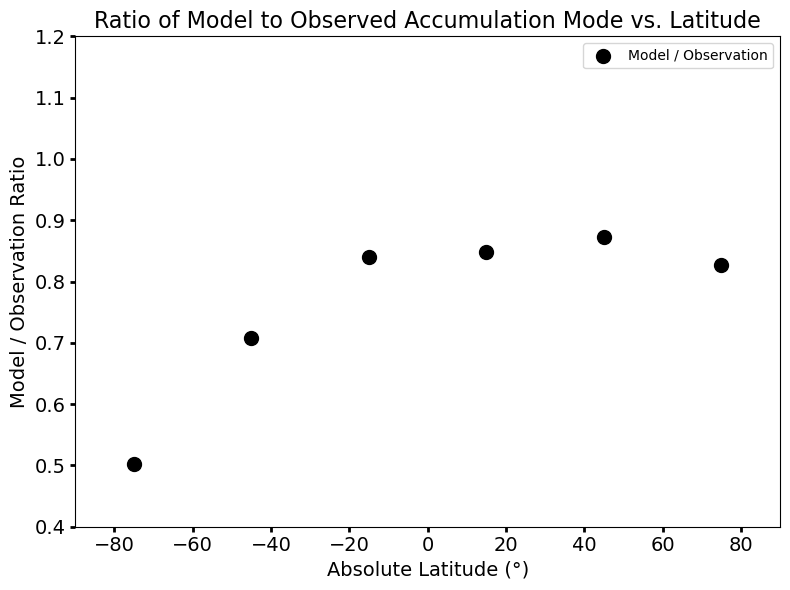

In [4]:
lat_bins = np.arange(-90, 91, 30)
lat_bin_centers = (lat_bins[:-1] + lat_bins[1:]) / 2
thres = 1000

# Initialize dictionaries to store campaign means
mean_fields = ['accum', 'accum_ins', 'aitken', 'aitken_ins', 'cor', 'cor_ins', 'total', 'obs']
campaign_means = {key: [] for key in mean_fields}

for lat_min, lat_max in zip(lat_bins[:-1], lat_bins[1:]):
    # Temporary storage for each campaign's mean per bin
    campaign_bin_means = {key: [] for key in mean_fields}

    for name, df in dfs.items():
        lat = df['latitude']
        mask = (lat >= lat_min) & (lat < lat_max)

        if not mask.any():
            continue  # skip this campaign if it has no points in this bin

        def masked_mean(var):
            m = var[mask]
            m = m[m <= thres]
            return np.nanmean(m) if len(m) > 0 else np.nan

        acc = df['model_accum']
        acc_ins = df['model_accum_insoluble']
        ait = df['model_aitken']
        ait_ins = df['model_aitken_insoluble']
        cor = df['model_cor']
        cor_ins = df['model_cor_insoluble']
        obs = df['num_accum_atom']

        total = acc + acc_ins + ait + ait_ins + cor + cor_ins

        # Collect means for this campaign in this lat bin
        campaign_bin_means['accum'].append(masked_mean(acc))
        campaign_bin_means['accum_ins'].append(masked_mean(acc_ins))
        campaign_bin_means['aitken'].append(masked_mean(ait))
        campaign_bin_means['aitken_ins'].append(masked_mean(ait_ins))
        campaign_bin_means['cor'].append(masked_mean(cor))
        campaign_bin_means['cor_ins'].append(masked_mean(cor_ins))
        campaign_bin_means['total'].append(masked_mean(total))
        campaign_bin_means['obs'].append(masked_mean(obs))

    # After collecting all campaigns for this bin, average them equally
    for key in mean_fields:
        vals = campaign_bin_means[key]
        campaign_means[key].append(np.nanmean(vals) if len(vals) > 0 else np.nan)


accum_mean      = np.array(campaign_means['accum'])
accum_ins_mean  = np.array(campaign_means['accum_ins'])
aitken_mean     = np.array(campaign_means['aitken'])
aitken_ins_mean = np.array(campaign_means['aitken_ins'])
cor_mean        = np.array(campaign_means['cor'])
cor_ins_mean    = np.array(campaign_means['cor_ins'])
total_mean      = np.array(campaign_means['total'])
total_obs_mean  = np.array(campaign_means['obs'])



factor_diff = total_mean/total_obs_mean
factor_diff
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(lat_bin_centers, factor_diff, color='black', label='Model / Observation', marker='o', s= 100)

# Add labels and title
ax.set_xlabel("Absolute Latitude (°)", fontsize=14)
ax.set_ylabel("Model / Observation Ratio", fontsize=14)
ax.set_title("Ratio of Model to Observed Accumulation Mode vs. Latitude", fontsize = 16)

# Optional: Add a reference line at 1 for visual comparison
#ax.axhline(1, color='gray', linestyle='--', linewidth=1)
ax.tick_params(axis='both', labelsize=14, width=2)  # Increase width of tick marks

# Show the plot with legend and grid
ax.legend(fontsize=14)
ax.set_ylim(0.4, 1.2)
ax.set_xlim(-90, 90)
# Show the plot
plt.legend()
#plt.grid(True)
plt.tight_layout()
#plt.savefig('./aerosols_ATom_ratio_need_to_fix.png', dpi=300, bbox_inches='tight')
plt.show()

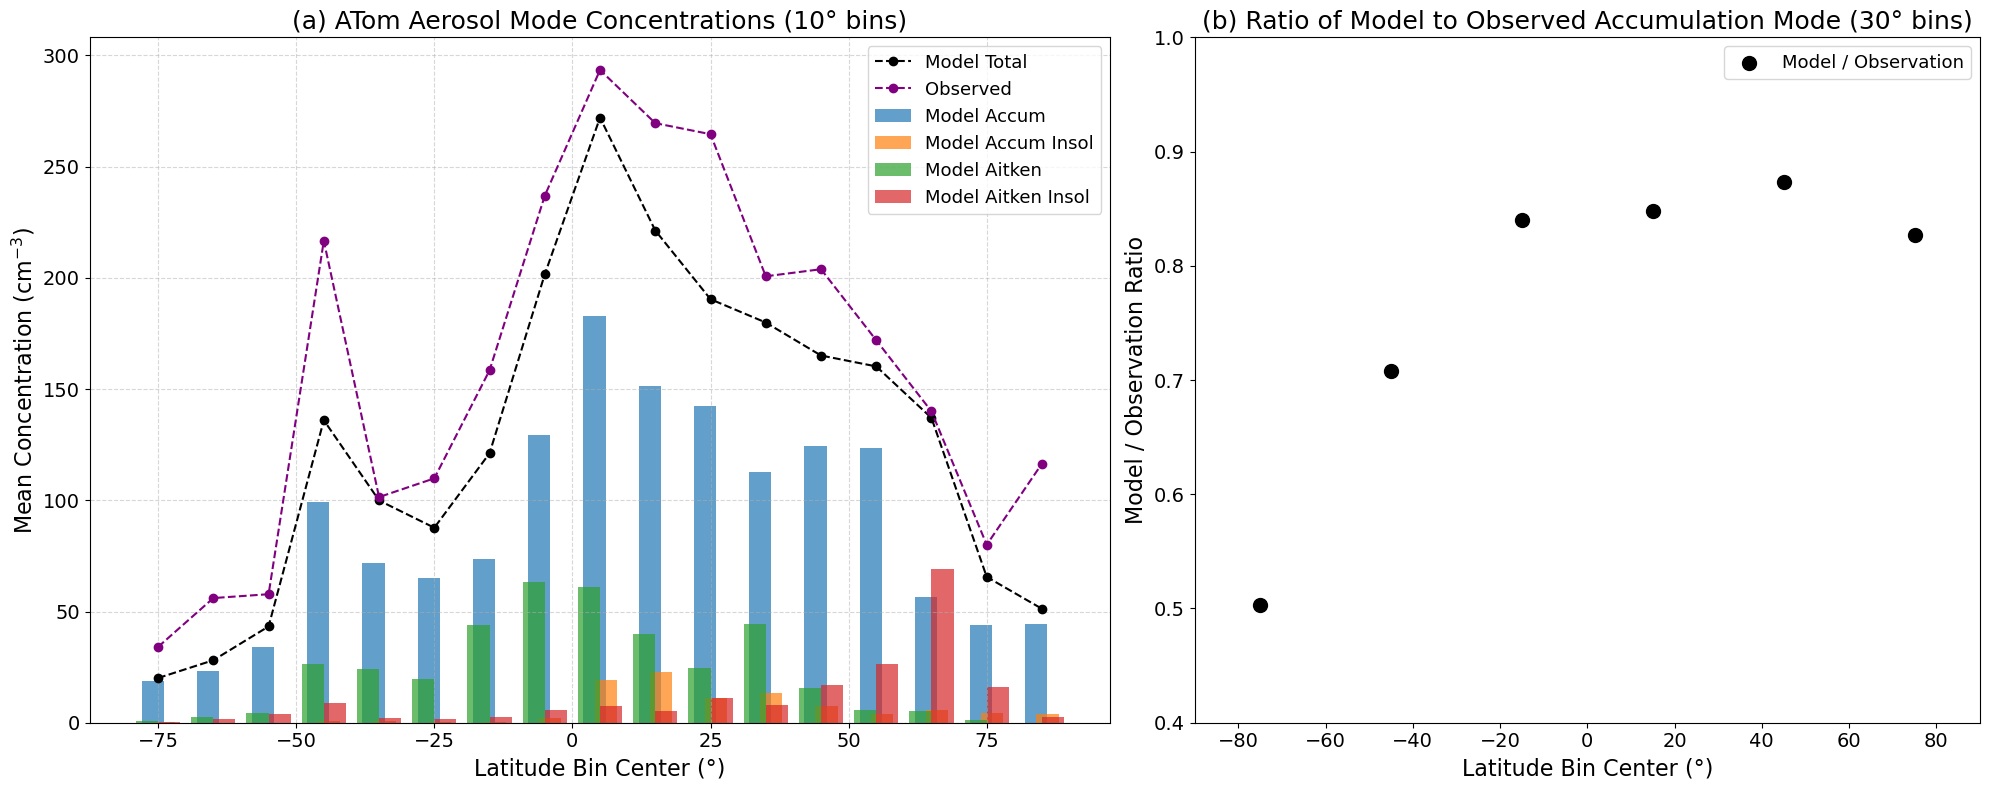

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------
# Load campaign data
# ------------------------------------------------------
dfs = {
    'ATom-1': pd.read_csv('atom_1_matched_model.csv'),
    'ATom-2': pd.read_csv('atom_2_matched_model.csv'),
    'ATom-3': pd.read_csv('atom_3_matched_model.csv'),
    'ATom-4': pd.read_csv('atom_4_matched_model.csv'),
}


# ------------------------------------------------------
# Function to compute latitude-binned means
# ------------------------------------------------------
def compute_lat_binned_means(dfs, lat_bins, thres=1000):
    mean_fields = ['accum', 'accum_ins', 'aitken', 'aitken_ins',
                   'cor', 'cor_ins', 'total', 'obs']
    campaign_means = {key: [] for key in mean_fields}

    lat_centers = (lat_bins[:-1] + lat_bins[1:]) / 2

    for lat_min, lat_max in zip(lat_bins[:-1], lat_bins[1:]):
        campaign_bin_means = {key: [] for key in mean_fields}

        for name, df in dfs.items():
            lat = df['latitude']
            mask = (lat >= lat_min) & (lat < lat_max)
            if not mask.any():
                continue

            # masked mean helper
            def masked_mean(var):
                m = var[mask]
                m = m[m <= thres]
                return np.nanmean(m) if len(m) > 0 else np.nan

            acc = df['model_accum']
            acc_ins = df['model_accum_insoluble']
            ait = df['model_aitken']
            ait_ins = df['model_aitken_insoluble']
            cor = df['model_cor']
            cor_ins = df['model_cor_insoluble']
            obs = df['num_accum_atom']

            total = acc + acc_ins + ait + ait_ins + cor + cor_ins

            campaign_bin_means['accum'].append(masked_mean(acc))
            campaign_bin_means['accum_ins'].append(masked_mean(acc_ins))
            campaign_bin_means['aitken'].append(masked_mean(ait))
            campaign_bin_means['aitken_ins'].append(masked_mean(ait_ins))
            campaign_bin_means['cor'].append(masked_mean(cor))
            campaign_bin_means['cor_ins'].append(masked_mean(cor_ins))
            campaign_bin_means['total'].append(masked_mean(total))
            campaign_bin_means['obs'].append(masked_mean(obs))

        # average campaigns equally
        for key in mean_fields:
            vals = campaign_bin_means[key]
            campaign_means[key].append(np.nanmean(vals) if len(vals) else np.nan)

    results = {key: np.array(campaign_means[key]) for key in mean_fields}
    results['lat_centers'] = lat_centers
    return results


# ------------------------------------------------------
# Compute 10° and 30° binned results
# ------------------------------------------------------
results_10 = compute_lat_binned_means(dfs, np.arange(-90, 91, 10))
results_30 = compute_lat_binned_means(dfs, np.arange(-90, 91, 30))

factor_diff = results_30['total'] / results_30['obs']


# ------------------------------------------------------
# Two-panel figure
# ------------------------------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(20, 8),
    gridspec_kw={'width_ratios': [1.3, 1]}
)

# ======================================================
# (a) Left panel: aerosol mode means (10° bins)
# ======================================================
ax = axes[0]
x = results_10['lat_centers']
bar_width = 4

ax.bar(x - 0.25*bar_width, results_10['accum'],      width=bar_width, color='tab:blue',   alpha=0.7, label='Model Accum')
ax.bar(x + 0.25*bar_width, results_10['accum_ins'],  width=bar_width, color='tab:orange', alpha=0.7, label='Model Accum Insol')
ax.bar(x - 0.50*bar_width, results_10['aitken'],     width=bar_width, color='tab:green',  alpha=0.7, label='Model Aitken')
ax.bar(x + 0.50*bar_width, results_10['aitken_ins'], width=bar_width, color='tab:red',    alpha=0.7, label='Model Aitken Insol')

ax.plot(x, results_10['total'], marker='o', linestyle='--', color='black',  label='Model Total')
ax.plot(x, results_10['obs'],   marker='o', linestyle='--', color='purple', label='Observed')

ax.set_xlabel('Latitude Bin Center (°)', fontsize=16)
ax.set_ylabel('Mean Concentration (cm$^{-3}$)', fontsize=16)
ax.set_title('(a) ATom Aerosol Mode Concentrations (10° bins)', fontsize=18)
ax.grid(True, linestyle='--', alpha=0.5)
ax.tick_params(labelsize=14)
ax.legend(fontsize=13)


# ======================================================
# (b) Right panel: model/obs ratio (30° bins)
# ======================================================
ax2 = axes[1]
ax2.scatter(results_30['lat_centers'], factor_diff, color='black', marker='o', s=100, label='Model / Observation')

ax2.set_xlabel('Latitude Bin Center (°)', fontsize=16)
ax2.set_ylabel('Model / Observation Ratio', fontsize=16)
ax2.set_title('(b) Ratio of Model to Observed Accumulation Mode (30° bins)', fontsize=18)
ax2.set_ylim(0.4, 1)
ax2.set_xlim(-90, 90)
ax2.tick_params(labelsize=14)
ax2.legend(fontsize=13)

plt.tight_layout()
plt.savefig('../images/aerosols_ATom_combined_two_panel.png', dpi=300, bbox_inches='tight')
plt.show()
